# 08 — GCN link prediction (Task 5, part 1)

First neural graph model in the project. Two-layer **Graph Convolutional Network** (Kipf & Welling 2017) on the same **Compound ∪ Gene ∪ Disease** walk graph nb05 uses, evaluated on the **locked** train/test split from nb04.

Compared with Node2Vec:

| Aspect | Node2Vec (nb05) | GCN (this nb) |
|---|---|---|
| Training | 2-stage: walks → Word2Vec | 1-stage: end-to-end via BCE on link labels |
| Uses labels? | No (unsupervised) | Yes (positive/negative link supervision) |
| Node features | none (structural only) | learnable `nn.Embedding` per node |
| Edge types | ignored (all edges same) | still ignored — GCN is homogeneous (R-GCN in nb09) |
| Compute | CPU, ~10 min at nb05 config | MPS (M-chip GPU), a few minutes |

**What this notebook answers**:
1. Does a simple GCN, on the same graph and same eval, beat Node2Vec+Concat+LR (AUROC 0.921)?
2. Is training stable with 604 positive edges? Loss curve should smoothly decrease.
3. Where does GCN win / lose vs Node2Vec on top-K? Reuses the nb06 structural feature table.

## 1 · Setup

In [1]:
from __future__ import annotations
import json, pathlib, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from utils import load_hetnet, setup_plot_style
setup_plot_style()

ART   = pathlib.Path("artifacts")
CACHE = pathlib.Path("cache/gcn"); CACHE.mkdir(parents=True, exist_ok=True)
assert ART.exists(), "Run nb4 to the end first — it writes artifacts/."

# --- Device selection: MPS on M-chip, else CPU ---
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using MPS (Apple GPU).")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using CUDA.")
else:
    device = torch.device("cpu")
    print(f"Using CPU (slow — expect several minutes per epoch).")


Using MPS (Apple GPU).


In [2]:
# --- Locked split (nb4) ---
meta  = json.loads((ART / "splits" / "split_meta.json").read_text())
pairs = pd.read_parquet(ART / "splits" / "pairs.parquet")
split = np.load(ART / "splits" / "lr_split.npz")
idx_train, idx_test = split["idx_train"], split["idx_test"]
SEED = int(meta["split_seed"])
y = pairs["y"].to_numpy()
n_pos_test = int(y[idx_test].sum())

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Pairs: {len(pairs):,} | positives: {int(y.sum())} | test positives: {n_pos_test}")


Pairs: 206,312 | positives: 755 | test positives: 151


## 2 · Build the walk graph (same as nb05)

Same three preprocessing steps: keep C+G+D only, drop the 151 test CtD edges, remove top-20 gene hubs, restrict to the largest connected component.  The graph structure feeds message passing; the CtD *labels* feed the loss.

In [3]:
HUB_K = 20
KEEP_KINDS = {"Compound", "Gene", "Disease"}

t0 = time.time()
hetnet = load_hetnet()
print(f"Loaded hetnet in {time.time() - t0:.1f}s")

G = nx.Graph()
for n in hetnet["nodes"]:
    if n["kind"] in KEEP_KINDS:
        G.add_node((n["kind"], n["identifier"]), kind=n["kind"], name=n["name"])
kept = set(G.nodes())
for e in hetnet["edges"]:
    u = tuple(e["source_id"]); v = tuple(e["target_id"])
    if u in kept and v in kept:
        G.add_edge(u, v, kind=e["kind"])

pos_mask = y == 1
test_mask = np.zeros(len(pairs), dtype=bool); test_mask[idx_test] = True
test_positives  = pairs.loc[pos_mask & test_mask,  ["compound", "disease"]]
train_positives = pairs.loc[pos_mask & ~test_mask, ["compound", "disease"]]

dropped = 0
for c, d in test_positives.itertuples(index=False):
    u, v = ("Compound", c), ("Disease", d)
    if G.has_edge(u, v):
        G.remove_edge(u, v); dropped += 1

gene_deg = sorted(((n, deg) for n, deg in G.degree() if n[0] == "Gene"), key=lambda x: -x[1])
G.remove_nodes_from([n for n, _ in gene_deg[:HUB_K]])
lcc_nodes = max(nx.connected_components(G), key=len)
G = G.subgraph(lcc_nodes).copy()

print(f"Walk graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges, "
      f"{dropped} test CtD edges dropped.")


Loaded hetnet in 13.4s


Walk graph: 19,683 nodes, 525,174 edges, 151 test CtD edges dropped.


## 3 · Convert to PyG `Data`

- `node_idx`: canonical `(kind, identifier) → int` index (0..N-1) that we use everywhere below.
- `edge_index`: 2 × 2E tensor listing (src, dst) for each edge in both directions — GCN needs directed edges for message passing.
- No `x` yet; we use learnable `nn.Embedding` in the model so every node gets a trainable d-dim vector.

In [4]:
node_list = list(G.nodes())
node_idx  = {n: i for i, n in enumerate(node_list)}
num_nodes = len(node_list)

# Directed edge_index (both directions) for GCNConv
src, dst = [], []
for u, v in G.edges():
    src.extend([node_idx[u], node_idx[v]])
    dst.extend([node_idx[v], node_idx[u]])
edge_index = torch.tensor([src, dst], dtype=torch.long)

data = Data(edge_index=edge_index, num_nodes=num_nodes)
print(f"PyG Data: num_nodes={data.num_nodes:,}, num_edges={data.num_edges:,} (directed).")

# Kind and name lookups for interpretation
node_kind = np.array([G.nodes[n]["kind"] for n in node_list])
node_name = np.array([G.nodes[n]["name"] for n in node_list])
compound_ids_in_G = {n[1]: node_idx[n] for n in node_list if n[0] == "Compound"}
disease_ids_in_G  = {n[1]: node_idx[n] for n in node_list if n[0] == "Disease"}
print(f"  Compounds in G: {len(compound_ids_in_G):,}")
print(f"  Diseases  in G: {len(disease_ids_in_G):,}")


PyG Data: num_nodes=19,683, num_edges=1,050,348 (directed).
  Compounds in G: 1,517
  Diseases  in G: 136


## 4 · Build labeled edge lists for training and evaluation

Two lists:
- **`train_pos_edges`**: (u, v) node-index tensor of length ≈ 604 — the training CtD positives.
- **`eval_edges`**: (u, v) tensor of length 206,312 covering the entire nb04 pair universe (both train and test). We score every pair once at eval time and slice by `idx_test`.

Any pair whose endpoints are missing from the walk graph (hub-removed genes never occur here; but some compounds/diseases could have been in isolated components before LCC restriction) gets a score of `-inf` so it sinks in the ranking.

In [5]:
def to_edge_tensor(df):
    us, vs, mask = [], [], []
    for c, d in df[["compound", "disease"]].itertuples(index=False):
        u = compound_ids_in_G.get(c, -1)
        v = disease_ids_in_G.get(d, -1)
        if u >= 0 and v >= 0:
            us.append(u); vs.append(v); mask.append(True)
        else:
            us.append(0); vs.append(0); mask.append(False)  # placeholder
    return (
        torch.tensor([us, vs], dtype=torch.long),
        torch.tensor(mask, dtype=torch.bool),
    )

train_pos_edges, _         = to_edge_tensor(train_positives)
eval_edges,      eval_have = to_edge_tensor(pairs)
print(f"Training positives : {train_pos_edges.size(1)}")
print(f"Eval pairs covered : {int(eval_have.sum())}/{len(pairs)}")


Training positives : 604
Eval pairs covered : 206312/206312


## 5 · The model

Two `GCNConv` layers (Kipf-Welling normalisation) with ReLU between, followed by a **dot-product decoder** that scores an edge (u, v) as `⟨emb_u, emb_v⟩`.

`nn.Embedding` gives every node a learnable 64-dim starting vector — role identical to Node2Vec's random init, but here it's optimised end-to-end via the link-prediction loss instead of via random-walk Skip-gram.

In [6]:
HIDDEN_DIM = 64
DROPOUT    = 0.2
LR         = 0.01
EPOCHS     = 200
NEG_RATIO  = 1   # negatives per positive per epoch


class GCNLinkPredictor(nn.Module):
    def __init__(self, num_nodes: int, hidden_dim: int, dropout: float):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.conv1 = GCNConv(hidden_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = dropout

    def encode(self, edge_index):
        x = self.node_emb.weight
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    @staticmethod
    def decode(z, edges):
        # edges: 2 x E long tensor
        return (z[edges[0]] * z[edges[1]]).sum(dim=-1)


model = GCNLinkPredictor(num_nodes, HIDDEN_DIM, DROPOUT).to(device)
data_edge_index = data.edge_index.to(device)
train_pos_dev   = train_pos_edges.to(device)
eval_edges_dev  = eval_edges.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: 2-layer GCN, hidden={HIDDEN_DIM}, params={n_params:,}")
print(f"Device: {device}")


Model: 2-layer GCN, hidden=64, params=1,268,032
Device: mps


## 6 · Training

Loss = binary cross entropy over an equal-sized positive/negative batch each epoch. Negatives are sampled uniformly among random (compound, disease) pairs *not* in the training positive set.

In [7]:
def sample_negative_edges(n_samples: int, exclude_edges_set: set, num_compounds, compound_indices, disease_indices, rng) -> torch.Tensor:
    us, vs = [], []
    tries = 0
    while len(us) < n_samples and tries < n_samples * 10:
        c_idx = compound_indices[rng.integers(0, len(compound_indices))]
        d_idx = disease_indices[rng.integers(0, len(disease_indices))]
        if (c_idx, d_idx) not in exclude_edges_set:
            us.append(c_idx); vs.append(d_idx)
        tries += 1
    return torch.tensor([us, vs], dtype=torch.long)


# Precompute exclusion set of training positive edges
train_pos_pairs = set(zip(train_pos_edges[0].tolist(), train_pos_edges[1].tolist()))
compound_indices = np.array([i for i, n in enumerate(node_list) if n[0] == "Compound"])
disease_indices  = np.array([i for i, n in enumerate(node_list) if n[0] == "Disease"])
rng = np.random.default_rng(SEED)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_history = []
auroc_history = []

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    # Sample fresh negatives each epoch
    n_pos = train_pos_dev.size(1)
    neg_edges = sample_negative_edges(n_pos * NEG_RATIO, train_pos_pairs,
                                      num_nodes, compound_indices, disease_indices, rng).to(device)

    z = model.encode(data_edge_index)
    pos_scores = model.decode(z, train_pos_dev)
    neg_scores = model.decode(z, neg_edges)

    scores = torch.cat([pos_scores, neg_scores])
    labels = torch.cat([torch.ones_like(pos_scores),
                        torch.zeros_like(neg_scores)])
    loss = F.binary_cross_entropy_with_logits(scores, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    loss_history.append(float(loss.item()))

    # Track eval AUROC every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            z_eval = model.encode(data_edge_index)
            scores_all = model.decode(z_eval, eval_edges_dev).cpu().numpy()
            scores_all[~eval_have.numpy()] = -1e9  # sink uncovered pairs
            auroc = roc_auc_score(y[idx_test], scores_all[idx_test])
        auroc_history.append((epoch, auroc))
        print(f"  epoch {epoch:3d}  loss={loss.item():.4f}  test AUROC={auroc:.4f}")

train_seconds = time.time() - t0
print(f"\nTraining done in {train_seconds:.1f}s")


  epoch   1  loss=0.6931  test AUROC=0.8304


  epoch  10  loss=0.4998  test AUROC=0.8375


  epoch  20  loss=0.4426  test AUROC=0.7952


  epoch  30  loss=0.3446  test AUROC=0.7743


  epoch  40  loss=0.3256  test AUROC=0.7767


...

  epoch 160  loss=0.1177  test AUROC=0.9048


  epoch 170  loss=0.1509  test AUROC=0.9097


  epoch 180  loss=0.1037  test AUROC=0.9159


  epoch 190  loss=0.1018  test AUROC=0.9213


  epoch 200  loss=0.0604  test AUROC=0.9218

Training done in 301.7s


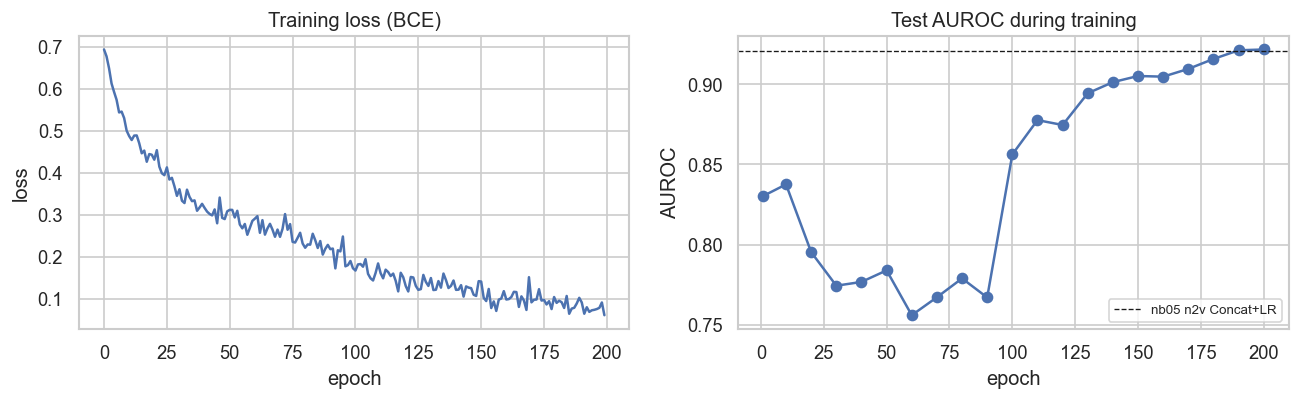

In [8]:
# Loss + AUROC training curve
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(loss_history)
axes[0].set(title="Training loss (BCE)", xlabel="epoch", ylabel="loss")
ep, ar = zip(*auroc_history)
axes[1].plot(ep, ar, marker="o")
axes[1].axhline(0.921, color="k", ls="--", lw=0.8, label="nb05 n2v Concat+LR")
axes[1].set(title="Test AUROC during training", xlabel="epoch", ylabel="AUROC")
axes[1].legend(fontsize=8)
plt.tight_layout()


## 7 · Final evaluation

Score all 206k pairs, slice by `idx_test`, compute AUROC + AUPRC + bootstrap 95 % CI, and drop into the same table as nb05 for direct comparison.

In [9]:
def bootstrap_ci(y_true, y_score, metric, B=500, seed=SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    vals = np.empty(B)
    for b in range(B):
        idx = rng.integers(0, n, n)
        if y_true[idx].sum() == 0:
            vals[b] = np.nan; continue
        vals[b] = metric(y_true[idx], y_score[idx])
    vals = vals[~np.isnan(vals)]
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


model.eval()
with torch.no_grad():
    z_final = model.encode(data_edge_index)
    score_gcn = model.decode(z_final, eval_edges_dev).cpu().numpy()
    score_gcn[~eval_have.numpy()] = -1e9  # sink uncovered pairs

y_test = y[idx_test]
s_test = score_gcn[idx_test]

auroc = roc_auc_score(y_test, s_test)
auprc = average_precision_score(y_test, s_test)
lo_roc, hi_roc = bootstrap_ci(y_test, s_test, roc_auc_score)
lo_pr,  hi_pr  = bootstrap_ci(y_test, s_test, average_precision_score)

# Top-K precision
prior = float(y_test.mean())
order = np.argsort(-s_test)
yy = y_test[order]
topk = {K: int(yy[:K].sum()) / K for K in [10, 50, 100, 500, 1000]}

# Load prior methods for a headline table
n2v_meta = json.loads((ART / "predictions" / "node2vec_meta.json").read_text())
prior_results = {
    r["method"]: {"AUROC": r["AUROC"], "AUPRC": r["AUPRC"]}
    for r in n2v_meta["results"]
}

rows = []
for name, r in prior_results.items():
    rows.append({"method": name, "AUROC": round(r["AUROC"], 4), "AUPRC": round(r["AUPRC"], 4)})
rows.append({
    "method": "gcn · 2-layer, dot decoder",
    "AUROC": round(auroc, 4), "AUPRC": round(auprc, 4),
})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

print(f"\nGCN AUROC 95% CI: [{lo_roc:.3f}, {hi_roc:.3f}]")
print(f"GCN AUPRC 95% CI: [{lo_pr:.4f}, {hi_pr:.4f}]")
print(f"Top-K precision (random baseline {prior:.4%}):")
for K, p in topk.items():
    print(f"  P@{K:<4d} = {p:.4f}  ({p/prior:.1f}x random)")


                        method  AUROC  AUPRC
      node2vec + Hadamard + LR 0.8594 0.0227
      node2vec + Concat   + LR 0.9209 0.0310
             node2vec + Cosine 0.7807 0.0176
spectral + Concat   + LR (nb4) 0.6811 0.0097
spectral + Cosine        (nb4) 0.6215 0.0058
    gcn · 2-layer, dot decoder 0.9218 0.1787

GCN AUROC 95% CI: [0.893, 0.949]
GCN AUPRC 95% CI: [0.1273, 0.2488]
Top-K precision (random baseline 0.3659%):
  P@10   = 0.7000  (191.3x random)
  P@50   = 0.4200  (114.8x random)
  P@100  = 0.2800  (76.5x random)
  P@500  = 0.1300  (35.5x random)
  P@1000 = 0.0830  (22.7x random)


## 8 · Persist

Write scores in the same shape as nb05's `node2vec.parquet` so the nb06 integration + gated-ensemble section can immediately re-run with GCN as a third method.

In [10]:
out = pairs[["compound", "disease", "y"]].copy()
out["score_gcn"] = score_gcn
out["in_test"]   = test_mask
out.to_parquet(ART / "predictions" / "gcn.parquet")

meta_gcn = {
    "method": "gcn",
    "library": f"torch {torch.__version__} + torch_geometric",
    "config": {
        "layers": 2, "hidden_dim": HIDDEN_DIM, "dropout": DROPOUT,
        "lr": LR, "epochs": EPOCHS, "neg_ratio": NEG_RATIO,
        "hub_K": HUB_K, "seed": SEED, "device": str(device),
        "train_seconds": round(train_seconds, 1),
    },
    "walk_graph": {
        "kinds_kept": sorted(KEEP_KINDS),
        "n_nodes": int(num_nodes),
        "n_edges_directed": int(edge_index.size(1)),
        "test_ctd_edges_removed": int(dropped),
        "coverage": float(eval_have.float().mean()),
    },
    "results": {
        "AUROC":      round(auroc, 4),
        "AUROC_95%":  [round(lo_roc, 4), round(hi_roc, 4)],
        "AUPRC":      round(auprc, 4),
        "AUPRC_95%":  [round(lo_pr, 4), round(hi_pr, 4)],
        "top_k":      {str(K): round(v, 4) for K, v in topk.items()},
        "lift_vs_random": {str(K): round(v / prior, 1) for K, v in topk.items()},
    },
    "training_curve": {
        "loss_last10": [round(x, 4) for x in loss_history[-10:]],
        "auroc_history": [(e, round(a, 4)) for e, a in auroc_history],
    },
    "compared_with": {r["method"]: r["AUROC"] for r in n2v_meta["results"]},
}
(ART / "predictions" / "gcn_meta.json").write_text(json.dumps(meta_gcn, indent=2, default=str))
print("Wrote:")
print("  artifacts/predictions/gcn.parquet")
print("  artifacts/predictions/gcn_meta.json")


Wrote:
  artifacts/predictions/gcn.parquet
  artifacts/predictions/gcn_meta.json


## 9 · Next up (nb09)

- Add **edge type awareness** via R-GCN (heterogeneous message passing, one weight matrix per relation).
- Compare `nb08 GCN` vs `nb09 R-GCN` to isolate whether edge-type awareness is what carries any GNN gain — or whether even the vanilla version already helps because of end-to-end training vs Node2Vec's 2-stage pipeline.
- Fold GCN + R-GCN into the nb06 gated-ensemble table.